<class 'pandas.core.frame.DataFrame'>
Int64Index: 48760 entries, 0 to 65534
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   latitude             48760 non-null  float64
 1   longitude            48760 non-null  float64
 2   node_id              48760 non-null  int64  
 3   segment_id           48760 non-null  int64  
 4   highway              48760 non-null  object 
 5   geohash              48760 non-null  object 
 6   geohash_crash_count  48760 non-null  int64  
 7   node_lat             48760 non-null  float64
 8   node_lon             48760 non-null  float64
 9   last_junction        48760 non-null  int64  
 10  next_junction        48760 non-null  int64  
 11  mini_roundabout      48760 non-null  int64  
 12  crossing             48760 non-null  int64  
 13  traffic_signals      48760 non-null  int64  
 14  give_way             48760 non-null  int64  
 15  stop                 48760 non-null 

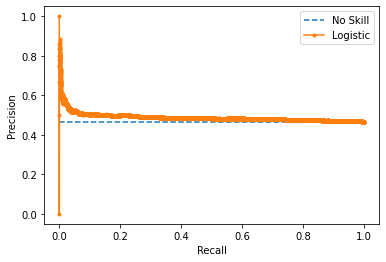

roc curve and auc:
No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.524


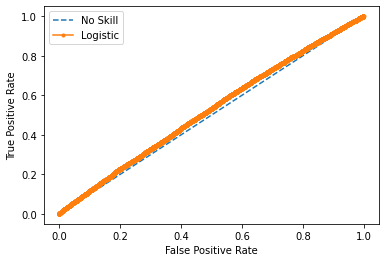

Runtime of the program is 21.648010969161987


In [34]:
import time
# starting time
start = time.time()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# precision-recall curve and f1
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc

# roc curve and auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from matplotlib import pyplot

dataset = pd.read_excel ('/content/Data set.csv')
dataset = dataset.dropna()
print(dataset.info())
dataset.head()
X = dataset.iloc[:, 0: -1].values
y = dataset.iloc[:, -1].values
from sklearn.preprocessing import LabelEncoder
LE1 = LabelEncoder()
X[:,4] = np.array(LE1.fit_transform(X[:,4]))
LE2 = LabelEncoder()
X[:,5] = np.array(LE2.fit_transform(X[:,5]))
LE3 = LabelEncoder()
X[:,32] = np.array(LE3.fit_transform(X[:,32]))
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct =ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[45])],remainder="passthrough")
X = np.array(ct.fit_transform(X))
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)
from sklearn.ensemble import RandomForestClassifier

regressor = RandomForestClassifier(n_estimators=80, random_state=0)

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Accident risk : ", accuracy_score(y_test, y_pred))

# precision-recall curve and f1
print("precision-recall curve and f1:")
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_test)
# predict probabilities
lr_probs = model.predict_proba(X_train)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# predict class values
yhat = model.predict(X_train)
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_probs)
lr_f1, lr_auc = f1_score(y_test, yhat), auc(lr_recall, lr_precision)
# summarize scores
print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
# plot the precision-recall curves
no_skill = len(y_test[y_test==1]) / len(y_test)
pyplot.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
pyplot.plot(lr_recall, lr_precision, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('Recall')
pyplot.ylabel('Precision')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# roc curve and auc
print("roc curve and auc:")
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(y_test))]
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_test)
# predict probabilities
lr_probs = model.predict_proba(X_train)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# calculate scores
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Hyperparameter code
import numpy as np
import pandas as pd
import sklearn
dataset = pd.read_excel ('/content/Data set.csv')
dataset = dataset.dropna()
print(dataset.info())
dataset.head()
X = dataset.iloc[:, 0: -1].values
y = dataset.iloc[:, -1].values
from sklearn.preprocessing import LabelEncoder
LE1 = LabelEncoder()
X[:,4] = np.array(LE1.fit_transform(X[:,4]))
LE2 = LabelEncoder()
X[:,5] = np.array(LE2.fit_transform(X[:,5]))
LE3 = LabelEncoder()
X[:,32] = np.array(LE3.fit_transform(X[:,32]))
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct =ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[45])],remainder="passthrough")
X = np.array(ct.fit_transform(X))
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
rf = RandomForestRegressor(random_state = 42)
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(rf.get_params())

from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

print('Random grid is:\n')   
pprint(random_grid)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestRegressor()
# Random search of parameters, using 2 fold cross validation, 
# search across 10 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 10, cv = 2, verbose=2, random_state=0, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train);

rf_random.best_params_
# Evaluate Random Search

def evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    errors = abs(predictions - y_test)
    mape = 100 * np.mean(errors / y_test)
    accuracy = 100 - mape
    print('Model Performance')
    print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(accuracy))
    
    return accuracy
base_model = RandomForestRegressor(n_estimators = 10, random_state = 42)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)
# Evaluate the Default Model
base_model = RandomForestRegressor(n_estimators = 10, random_state = 42)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)
# Evaluate the Best Random Search Model
best_random = rf_random.best_estimator_
random_accuracy = evaluate(best_random, X_test, y_test)

print('Improvement of {:0.2f}%.'.format( 100 * (random_accuracy - base_accuracy) / base_accuracy))


# end time
end = time.time()

# total time taken
print(f"Runtime of the program is {end - start}")